# Magnetism

Magnetism is only available in Refl1d, and refl1d itself does not support magnetic layers inside a `RepeatingMultilayer` (it raises `NotImplementedError` rather than silently producing a wrong profile).

When magnetism is enabled (`include_magnetism = True`) all four polarization channels are available: the non-spin-flip channels (`pp`, `mm`) and the spin-flip channels (`pm`, `mp`).

## Setup

In [1]:
%matplotlib inline

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import refl1d
import refl1d.names
import scipp as sc

import easyreflectometry
from easyreflectometry.calculators import CalculatorFactory
from easyreflectometry.calculators.refl1d.wrapper import _get_polarized_probe
from easyreflectometry.model import Model
from easyreflectometry.model import PercentageFwhm
from easyreflectometry.sample import Layer
from easyreflectometry.sample import LayerMagnetism
from easyreflectometry.sample import Material
from easyreflectometry.sample import Multilayer
from easyreflectometry.sample import Sample

For reference we fetch the version of the software packages we are using. 

In [3]:
print(f'numpy: {np.__version__}')
print(f'scipp: {sc.__version__}')
print(f'easyreflectometry: {easyreflectometry.__version__}')
print(f'refl1d: {refl1d.__version__}')

numpy: 2.4.4
scipp: 26.3.1
easyreflectometry: 999.0.0
refl1d: 1.0.1


## Building our model

The system that was used to produce the data shown above is based on a silicon subphase with two layers upon it. 
These two layers are charachterized by having a scattering length density (SLD) of respectively 4 and 8.
Both layers have a rougness of 0 but their thicknesses are 100 and 150 angstrom respectively.
We show the model that will be used graphically below. 

<center>
    <img src='two_layers.png' alt='A slab model description of the two_layers system.' width='300px'></img>
</center>
<center>
    A slab model description of the two layer.
</center>

To construct such a layer structure, first we create each of the materials, the associated layers, and the sub and super phases. 

In [4]:
sld_4 = Material(sld=4.0, isld=0, name='Sld 4')
sld_4_layer = Layer(material=sld_4, thickness=100, roughness=0, name='SLD 4 Layer')

sld_8 = Material(sld=8.0, isld=0, name='Sld 8')
sld_8_layer = Layer(material=sld_8, thickness=150, roughness=0, name='SLD 8 Layer')

vacuum = Material(sld=0, isld=0, name='Vacuum')
superphase = Layer(material=vacuum, thickness=0, roughness=0, name='Vacuum Superphase')

si = Material(sld=2.047, isld=0, name='Si')
subphase = Layer(material=si, thickness=0, roughness=0, name='Si Subphase')

We then create a model for the two layered structures.

In [5]:
two_layers = Multilayer([sld_4_layer, sld_8_layer], name='SLD 4/8 Layer')
sample = Sample(Multilayer(superphase), two_layers, Multilayer(subphase), name='Two Layer Sample')
model = Model(
    sample=sample,
    scale=1,
    background=0,
    name='Two Layer Model',
)

We also need a Refl1d sample

In [6]:
refl1d_sld_4 = refl1d.names.SLD(name='Sld 4', rho=4.0, irho=0)
refl1d_sld_8 = refl1d.names.SLD(name='Sld 8', rho=8.0, irho=0)
refl1d_vacuum = refl1d.names.SLD(name='Vacuum', rho=0, irho=0)
refl1d_si = refl1d.names.SLD(name='Si', rho=2.047, irho=0)

# Refl1d model is inverted as compared to EasyReflectometry, so the order of the layers is reversed
refl1d_sample = refl1d_si(0, 0) | refl1d_sld_8(150, 0) | refl1d_sld_4(100, 0) | refl1d_vacuum(0, 0)

## Prepare interface factory

We will use the [Ref1d](https://refl1d.readthedocs.io/en/latest/) and [Refnx](https://refnx.readthedocs.io/) calculator for our analysis. 

In [7]:
interface = CalculatorFactory()

## Comparisons
To validate the implementation we do some comparisons of the reflectevity determined in EasyReflectometry using different calculators or directly in Refl1d.

In [8]:
model_coords = np.linspace(
    start=0.001,
    stop=0.3,
    num=1000,
)


def plot_apply_makeup():
    ax = plt.gca()
    ax.set_xlim([-0.01, 0.35])
    ax.set_ylim([1e-8, 2.5])
    plt.legend()
    plt.yscale('log')
    plt.show()

### Refl1d and EasyReflectometry without magnetism
First we will ensure that the Refl1d calculator is correctly implemented in EasyReflectometry when no magnetic effects are present.

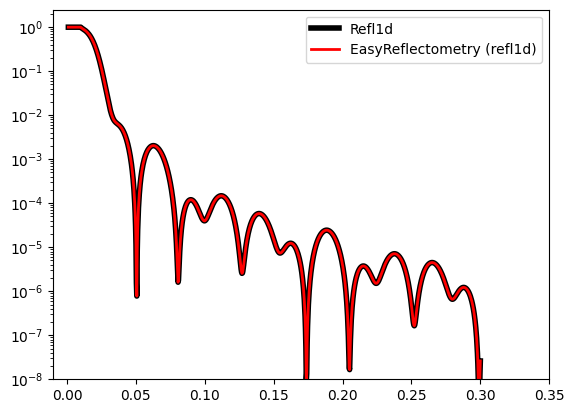

In [9]:
# Refl1d
probe = refl1d.names.QProbe(
    Q=model_coords,
    dQ=np.zeros(len(model_coords)),
    intensity=1,
    background=0,
)
experiment = refl1d.names.Experiment(probe=probe, sample=refl1d_sample)
model_data_no_magnetism_ref1d_raw = experiment.reflectivity()[1]

plt.plot(model_coords, model_data_no_magnetism_ref1d_raw, '-k', label='Refl1d', linewidth=4)

# EasyReflectometry
interface.switch('refl1d')
model.interface = interface
model.resolution_function = PercentageFwhm(0)
model_interface = model.interface()
model_interface.include_magnetism = False
model_data_no_magnetism_ref1d_easy = model.interface().reflectity_profile(
    model_coords,
    model.unique_name,
)
plt.plot(
    model_coords, model_data_no_magnetism_ref1d_easy, 'r-', label=f'EasyReflectometry ({model_interface.name})', linewidth=2
)

plot_apply_makeup()

### EasyReflectometry with and without magnetic layers
We have now reached the point where we can do sa simulation for a sample with magnetic layers.  For this sample we should see a difference in the determined reflectivity.

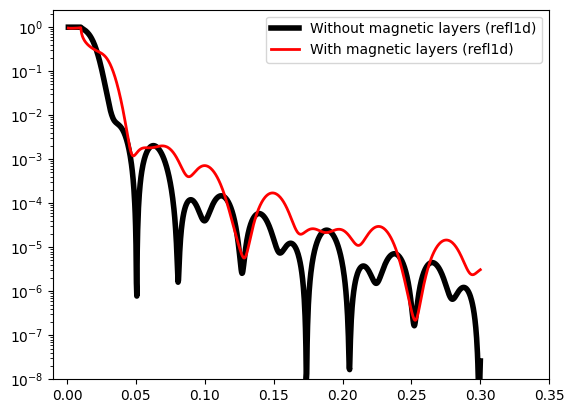

In [10]:
# Without magnetic layers
interface.switch('refl1d')
model.interface = interface
model_interface = model.interface()
model_interface.include_magnetism = True
model_data_magnetism = model.interface().reflectity_profile(
    model_coords,
    model.unique_name,
)
plt.plot(model_coords, model_data_magnetism, '-k', label=f'Without magnetic layers ({model_interface.name})', linewidth=4)

# With magnetic layers
interface.switch('refl1d')
model.interface = interface
sld_4_layer.magnetism = LayerMagnetism(rho_m=10, theta_m=70, name='Sld 4 moment')
sld_8_layer.magnetism = LayerMagnetism(rho_m=5, theta_m=175, name='Sld 8 moment')
model_interface = model.interface()
model_data_magnetism_layer_1 = model.interface().reflectity_profile(
    model_coords,
    model.unique_name,
)
plt.plot(model_coords, model_data_magnetism_layer_1, 'r-', label=f'With magnetic layers ({model_interface.name})', linewidth=2)

plot_apply_makeup()

As expected do we see a difference in the reflectivity profile for a sample with and without magnetic layers.

### EasyReflectometry and Refl1d with magnetism
The final comparison is to confirm that that we are able to reproduce the raw Refl1d reflectometry in EasyReflectometry when acocunting for magnetism.

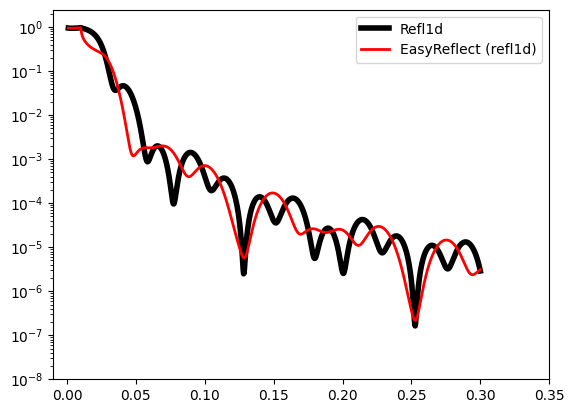

In [11]:
# Refl1d model is inverted as compared to EasyReflectometry, so the order of the layers is reversed
refl1d_sample = (
    refl1d_si(0, 0)
    | refl1d_sld_8(150, 0, magnetism=refl1d.names.Magnetism(rhoM=5, thetaM=175))
    | refl1d_sld_4(100, 0, magnetism=refl1d.names.Magnetism(rhoM=10, thetaM=70))
    | refl1d_vacuum(0, 0)
)
model_name = model.unique_name
storage = {'model': {model_name: {}}}
# Match the EasyReflectometry model: scale=1, background=0
storage['model'][model_name]['scale'] = 1.0
storage['model'][model_name]['bkg'] = 0.0

polarized_probe = _get_polarized_probe(
    q_array=model_coords, dq_array=np.zeros(len(model_coords)), model_name=model_name, storage=storage
)

experiment = refl1d.names.Experiment(probe=polarized_probe, sample=refl1d_sample)
model_data_magnetism_ref1d = experiment.reflectivity()[0][1]
plt.plot(model_coords, model_data_magnetism_ref1d, '-k', label='Refl1d', linewidth=4)

# EasyReflectometry
interface.switch('refl1d')
model.interface = interface
sld_4_layer.magnetism = LayerMagnetism(rho_m=10, theta_m=70, name='Sld 4 moment')
sld_8_layer.magnetism = LayerMagnetism(rho_m=5, theta_m=175, name='Sld 8 moment')
model_interface = model.interface()
model_data_magnetism_easy = model.interface().reflectity_profile(
    model_coords,
    model.unique_name,
)
plt.plot(model_coords, model_data_magnetism_easy, 'r-', label=f'EasyReflect ({model_interface.name})', linewidth=2)

plot_apply_makeup()

The two models agree when the magnetic parameters are the same.

In [12]:
print(max(abs(model_data_magnetism_easy - model_data_magnetism_ref1d)))

0.4610844803663004


## Afterthoughts 
Just for completion we will do a few additional calculations and comparisons of reflectivity.

## All polarization channels for a single layer sample

This study is done with magnetism to show the reflectivity of all four spin cross-sections. First we compute the reference directly in Refl1d for a single magnetic layer on a silicon subphase.

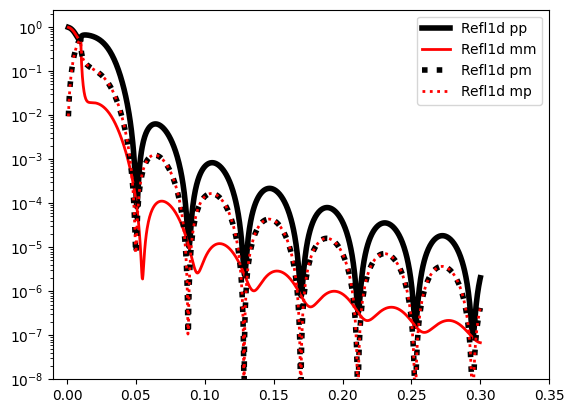

In [13]:
# The magnetic SLD is set to 8 and its angle to 45 degrees.
# An angle of 90 would double (pp) and cancel out (mm) the magnitude of the reflectivity oscillations,
# while an angle of 0 would give the strongest spin-flipping (pm and mp).
# At 45 degrees neither effect is maximized, so all four channels are distinct.
refl1d_sample = (
    refl1d_si(0, 0) | refl1d_sld_8(150, 0, magnetism=refl1d.names.Magnetism(rhoM=8, thetaM=45)) | refl1d_vacuum(0, 0)
)

model_name = model.unique_name
storage = {'model': {model_name: {}}}
storage['model'][model_name]['scale'] = 1.0
storage['model'][model_name]['bkg'] = 0.0

polarized_probe = _get_polarized_probe(
    q_array=model_coords, dq_array=np.zeros(len(model_coords)), model_name=model_name, storage=storage
)

experiment = refl1d.names.Experiment(probe=polarized_probe, sample=refl1d_sample)
# One reflectivity() call returns all four cross-sections, in the order pp, pm, mp, mm
raw_reflectivities = experiment.reflectivity()
raw_channels = {key: reflectivity for key, (_, reflectivity) in zip(('pp', 'pm', 'mp', 'mm'), raw_reflectivities)}

plt.plot(model_coords, raw_channels['pp'], '-k', label='Refl1d pp', linewidth=4)
plt.plot(model_coords, raw_channels['mm'], '-r', label='Refl1d mm', linewidth=2)
plt.plot(model_coords, raw_channels['pm'], ':k', label='Refl1d pm', linewidth=4)
plt.plot(model_coords, raw_channels['mp'], ':r', label='Refl1d mp', linewidth=2)

plot_apply_makeup()

### All polarization channels in EasyReflectometry

The same four channels are available through the EasyReflectometry API via `polarized_reflectivity_profiles`, which returns a dictionary keyed `pp`, `pm`, `mp`, `mm`. We build the equivalent single layer model and attach a `LayerMagnetism` to its layer, which makes it magnetic and enables `include_magnetism` automatically.

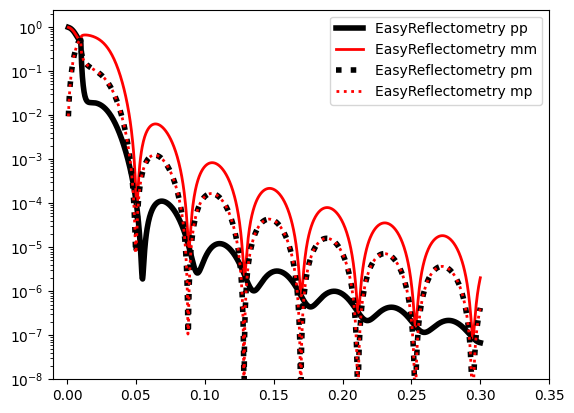

In [14]:
# The single layer model matching the raw Refl1d sample above
vacuum_single = Material(sld=0, isld=0, name='Vacuum')
sld_8_single = Material(sld=8.0, isld=0, name='Sld 8')
si_single = Material(sld=2.047, isld=0, name='Si')
superphase_single = Layer(material=vacuum_single, thickness=0, roughness=0, name='Vacuum Superphase')
magnetic_layer = Layer(material=sld_8_single, thickness=150, roughness=0, name='Magnetic Layer')
subphase_single = Layer(material=si_single, thickness=0, roughness=0, name='Si Subphase')
single_layer_model = Model(
    sample=Sample(
        Multilayer(superphase_single),
        Multilayer(magnetic_layer),
        Multilayer(subphase_single),
        name='Single Layer Sample',
    ),
    scale=1,
    background=0,
    name='Single Layer Model',
)

interface.switch('refl1d')
single_layer_model.interface = interface
single_layer_model.resolution_function = PercentageFwhm(0)
magnetic_layer.magnetism = LayerMagnetism(rho_m=8, theta_m=45, name='Magnetic layer moment')
model_interface = single_layer_model.interface()

channels = single_layer_model.interface.polarized_reflectivity_profiles(
    model_coords,
    single_layer_model.unique_name,
)

plt.plot(model_coords, channels['pp'], '-k', label='EasyReflectometry pp', linewidth=4)
plt.plot(model_coords, channels['mm'], '-r', label='EasyReflectometry mm', linewidth=2)
plt.plot(model_coords, channels['pm'], ':k', label='EasyReflectometry pm', linewidth=4)
plt.plot(model_coords, channels['mp'], ':r', label='EasyReflectometry mp', linewidth=2)

plot_apply_makeup()

The two models agree for every polarization channel.

In [15]:
for key in channels:
    print(f'{key}: {max(abs(channels[key] - raw_channels[key]))}')

pp: 0.6428054163967881
pm: 2.7200464103316335e-15
mp: 1.2212453270876722e-15
mm: 0.6428054163967881


### Selecting a single channel

`reflectity_profile` — the function used when fitting — returns the channel selected by `polarization_channel` (default `pp`). To fit against, say, `mm` data, select the `mm` channel.

Note that the selected channel is state of the currently active calculator: it affects every model and fit using that calculator until it is changed, and `interface.switch(...)` constructs a fresh calculator, which resets the channel (along with `include_magnetism`).

In [16]:
model_interface.polarization_channel = 'mm'
reflectivity_mm = single_layer_model.interface().reflectity_profile(
    model_coords,
    single_layer_model.unique_name,
)
print(f'mm channel reproduced: {max(abs(reflectivity_mm - channels["mm"]))}')

# Reset to the default channel so later cells are unaffected
model_interface.polarization_channel = 'pp'

mm channel reproduced: 0.0


### Magnetic SLD profile

Alongside the nuclear SLD profile (`sld_profile`), the magnetic components are available through `magnetic_sld_profile`, which returns `z`, the nuclear SLD, the magnetic SLD (`rhoM`) and the magnetic angle (`thetaM`). Like the polarized reflectivities it requires `include_magnetism` to be enabled and is only available for the Refl1d calculator.

Below we display the profiles for the single magnetic layer sample used above. The nuclear and magnetic SLD share the same unit ($10^{-6}$ Å$^{-2}$) so they are shown on one axis; the magnetic angle is constant (45 degrees) inside the layer.

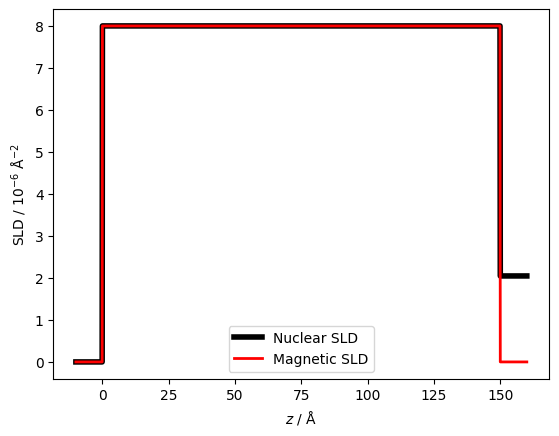

Magnetic angle inside the layer: 45.0 degrees


In [17]:
z, sld, sld_magnetic, theta_magnetic = single_layer_model.interface.magnetic_sld_profile(single_layer_model.unique_name)

# In this sample the nuclear and magnetic SLD are both 8 inside the layer, so the curves overlap there
plt.plot(z, sld, '-k', label='Nuclear SLD', linewidth=4)
plt.plot(z, sld_magnetic, '-r', label='Magnetic SLD', linewidth=2)
plt.xlabel(r'$z$ / Å')
plt.ylabel(r'SLD / $10^{-6}$ Å$^{-2}$')
plt.legend()
plt.show()

inside_layer = (z > 25) & (z < 125)
print(f'Magnetic angle inside the layer: {theta_magnetic[inside_layer].mean():.1f} degrees')

The profiles reproduce the ones determined directly by Refl1d for the equivalent sample (`magnetic_smooth_profile`). Since the Refl1d sample is built in the reverse order, its profiles are flipped before comparing.

In [18]:
# `experiment` is the raw Refl1d experiment for the single magnetic layer sample defined above
raw_z, raw_sld, _, raw_sld_magnetic, raw_theta_magnetic = experiment.magnetic_smooth_profile()

print(f'sld: {max(abs(sld - raw_sld[::-1]))}')
print(f'magnetic sld: {max(abs(sld_magnetic - raw_sld_magnetic[::-1]))}')
print(f'magnetic angle: {max(abs(theta_magnetic - raw_theta_magnetic[::-1]))}')

sld: 0.0
magnetic sld: 0.0
magnetic angle: 225.0


## EasyReflectometry with and without magnetism but no magnetic layers
We also want to confirm that we can enable the ability to account for magnetism without causing any significant changes to the reflectivity as determined for a sample without any magnetic layers.

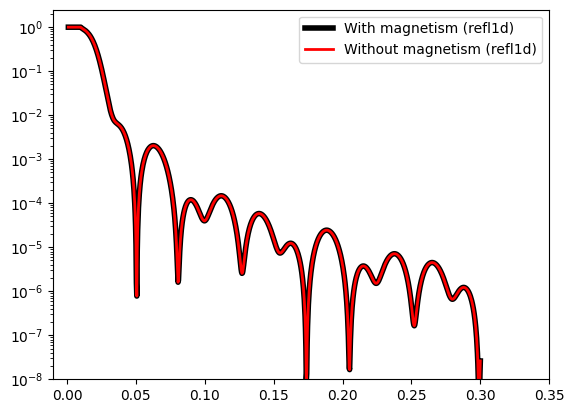

In [19]:
# The magnetic layers attached earlier in this tutorial live on the `Layer`
# objects themselves (unlike the old wrapper-storage workaround, which was
# scoped to one calculator instance and reset on every `interface.switch(...)`).
# Detach them so this section demonstrates its own point: a sample with no
# magnetic layers at all.
sld_4_layer.magnetism = None
sld_8_layer.magnetism = None

# With Magnetism
interface.switch('refl1d')
model.interface = interface
model_interface = model.interface()
model_interface.include_magnetism = True
model_data_magnetism = model.interface().reflectity_profile(
    model_coords,
    model.unique_name,
)
plt.plot(model_coords, model_data_magnetism, '-k', label=f'With magnetism ({model_interface.name})', linewidth=4)

# Without Magnetism
interface.switch('refl1d')
model.interface = interface
model_interface = model.interface()
model_interface.include_magnetism = False
model_data_no_magnetism = model.interface().reflectity_profile(
    model_coords,
    model.unique_name,
)
plt.plot(model_coords, model_data_no_magnetism, 'r-', label=f'Without magnetism ({model_interface.name})', linewidth=2)

plot_apply_makeup()

We don't see any change in the determined reflectivity when enabling the ability to account for magnetism for a sample without any magnetic layers, even though magnetic samples are handled with a `PolarizedQProbe` (Refl1d) whereas non-magnetic samples are handled with a `QProbe` (Refl1d).

In [20]:
print(max(abs(model_data_no_magnetism - model_data_magnetism)))

6.585414435988923e-10
